In [1]:
!pip install fastmri


In [2]:
import os
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split
import numpy as np
import h5py
import glob
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import fastmri
from fastmri.data import transforms as T
from fastmri.data.subsample import RandomMaskFunc
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [3]:
import random
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [4]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
data_dir = "/content/drive/MyDrive/fastMRI/multicoil_train"
cache_dir = "/content/fastmri_cache_4x"

os.makedirs(cache_dir, exist_ok=True)

files = sorted(glob.glob(os.path.join(data_dir, "*.h5")))

print("Number of H5 files:", len(files))
print(files[:3])

Number of H5 files: 885
['/content/drive/MyDrive/fastMRI/multicoil_train/2022061003_T103.h5', '/content/drive/MyDrive/fastMRI/multicoil_train/2022061003_T201.h5', '/content/drive/MyDrive/fastMRI/multicoil_train/2022061003_T202.h5']


# Normalisation and Dataset class

In [6]:
class MRISliceDataset(Dataset):
    def __init__(self, file_list, center_fraction=0.08, acceleration=4, max_slices_per_file=18):
        self.mask_func = RandomMaskFunc(
            center_fractions=[center_fraction],
            accelerations=[acceleration]
        )

        self.examples = []

        for fp in file_list:
            with h5py.File(fp, "r") as hf:
                num_slices = hf["kspace"].shape[0]

            for s in range(min(num_slices, max_slices_per_file)):
                self.examples.append((fp, s))

    def __len__(self):
        return len(self.examples)

    def __getitem__(self, idx):
        fp, s = self.examples[idx]

        with h5py.File(fp, "r") as hf:
            kspace = hf["kspace"][s]
            target = hf["reconstruction_rss"][s].astype(np.float32)

        kspace_t = T.to_tensor(kspace)

        masked_kspace, _, _ = T.apply_mask(
            kspace_t,
            self.mask_func,
            seed=SEED
        )

        zf_img = fastmri.ifft2c(masked_kspace)
        zf_abs = fastmri.complex_abs(zf_img)
        zf_rss = fastmri.rss(zf_abs, dim=0).numpy().astype(np.float32)

        scale = target.max()

        if scale > 0:
            zf_rss = zf_rss / scale
            target = target / scale

        zf_rss = np.clip(zf_rss, 0, 1)
        target = np.clip(target, 0, 1)

        x = torch.tensor(zf_rss, dtype=torch.float32).unsqueeze(0)
        y = torch.tensor(target, dtype=torch.float32).unsqueeze(0)

        return x, y

In [7]:
small_files = files[:50]

raw_dataset = MRISliceDataset(
    small_files,
    center_fraction=0.08,
    acceleration=4,
    max_slices_per_file=18
)

for idx in range(len(raw_dataset)):
    cache_path = os.path.join(cache_dir, f"slice_{idx:04d}.pt")

    if not os.path.exists(cache_path):
        x, y = raw_dataset[idx]
        torch.save({"x": x, "y": y}, cache_path)

print("Cached slices:", len(glob.glob(os.path.join(cache_dir, "*.pt"))))

Cached slices: 900


# Build the dataset and loaders

In [8]:
data_dir = r"/content/drive/MyDrive/fastMRI/multicoil_train"

files = sorted(glob.glob(os.path.join(data_dir, "*.h5")))
small_files = files[:50]

dataset = MRISliceDataset(
    small_files,
    center_fraction=0.08,
    acceleration=4,
    max_slices_per_file=18
)

split_generator = torch.Generator().manual_seed(SEED)

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(
    dataset,
    [train_size, val_size],
    generator=split_generator
)

train_loader = DataLoader(
    train_dataset,
    batch_size=4,
    shuffle=True,
    num_workers=0
)

val_loader = DataLoader(
    val_dataset,
    batch_size=4,
    shuffle=False,
    num_workers=0
)

print("Total slices:", len(dataset))
print("Train slices:", len(train_dataset))
print("Validation slices:", len(val_dataset))

Total slices: 900
Train slices: 720
Validation slices: 180


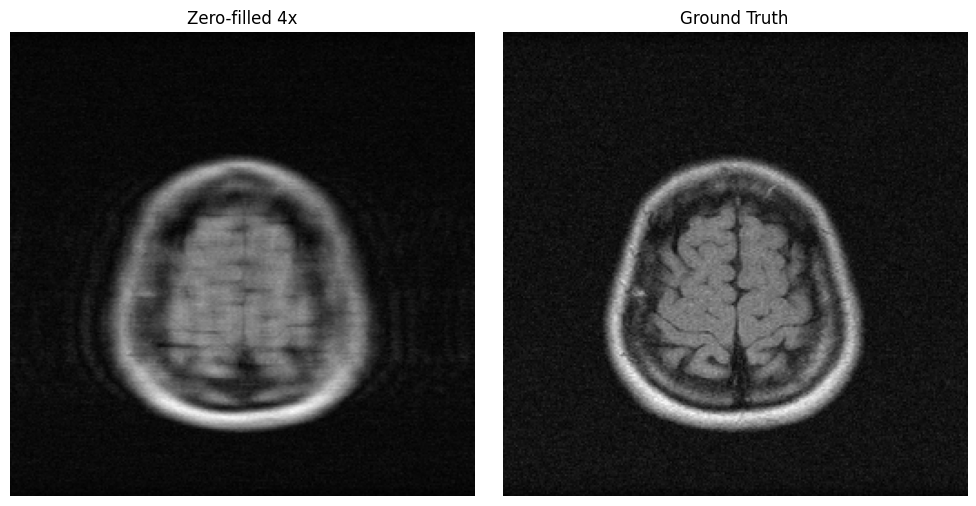

Input range: 0.00919172540307045 to 0.9466983675956726
Target range: 0.01528923399746418 to 1.0


In [9]:
# SMall data check
x, y = dataset[0]

plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(x[0].numpy(), cmap="gray")
plt.title("Zero-filled 4x")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(y[0].numpy(), cmap="gray")
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

print("Input range:", x.min().item(), "to", x.max().item())
print("Target range:", y.min().item(), "to", y.max().item())

# Build deeper Res UNet

In [10]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()

        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),

            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.net(x)


class UNetBetter(nn.Module):
    def __init__(self):
        super().__init__()

        self.down1 = DoubleConv(1, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.down2 = DoubleConv(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.down3 = DoubleConv(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bridge = DoubleConv(128, 256)

        self.up3 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.conv3 = DoubleConv(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.conv2 = DoubleConv(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.conv1 = DoubleConv(64, 32)

        self.out = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        d1 = self.down1(x)
        d2 = self.down2(self.pool1(d1))
        d3 = self.down3(self.pool2(d2))

        b = self.bridge(self.pool3(d3))

        u3 = self.up3(b)
        u3 = self.conv3(torch.cat([u3, d3], dim=1))

        u2 = self.up2(u3)
        u2 = self.conv2(torch.cat([u2, d2], dim=1))

        u1 = self.up1(u2)
        u1 = self.conv1(torch.cat([u1, d1], dim=1))

        correction = self.out(u1)

        return x + correction

In [11]:
#Create model, loss, optimizer and scheduler
model = UNetBetter().to(device)

criterion = nn.L1Loss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-3
)

scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=0.5,
    patience=3
)

print("Trainable parameters:", sum(
    p.numel() for p in model.parameters() if p.requires_grad
))

Trainable parameters: 1925025


In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for x, y in loader:
        x = x.to(device)
        y = y.to(device)

        optimizer.zero_grad()

        pred = model(x)
        loss = criterion(pred, y)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)


def validate_one_epoch(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)

            pred = model(x)
            loss = criterion(pred, y)

            total_loss += loss.item() * x.size(0)

    return total_loss / len(loader.dataset)

# Training the UNet, saving the best epoch based on PSNR and SSIM metrics

In [13]:
num_epochs = 30

train_losses = []
val_losses = []

best_val_loss = float("inf")

for epoch in range(num_epochs):
    train_loss = train_one_epoch(
        model, train_loader, optimizer, criterion, device
    )

    val_loss = validate_one_epoch(
        model, val_loader, criterion, device
    )

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    if val_loss < best_val_loss:
        best_val_loss = val_loss

        torch.save(
            {
                "epoch": epoch + 1,
                "model_state_dict": model.state_dict(),
                "optimizer_state_dict": optimizer.state_dict(),
                "val_loss": val_loss,
                "center_fraction": 0.08,
                "acceleration": 4,
                "seed": SEED,
            },
            "best_unetbetter_4x_seed42.pth"
        )

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"Train: {train_loss:.4f} | "
        f"Validation: {val_loss:.4f} | "
        f"LR: {optimizer.param_groups[0]['lr']:.1e}"
    )

Epoch 1/30 | Train: 0.0403 | Validation: 0.0358 | LR: 1.0e-03
Epoch 2/30 | Train: 0.0358 | Validation: 0.0359 | LR: 1.0e-03
Epoch 3/30 | Train: 0.0349 | Validation: 0.0345 | LR: 1.0e-03
Epoch 4/30 | Train: 0.0341 | Validation: 0.0331 | LR: 1.0e-03
Epoch 5/30 | Train: 0.0323 | Validation: 0.0304 | LR: 1.0e-03
Epoch 6/30 | Train: 0.0293 | Validation: 0.0278 | LR: 1.0e-03
Epoch 7/30 | Train: 0.0275 | Validation: 0.0267 | LR: 1.0e-03
Epoch 8/30 | Train: 0.0264 | Validation: 0.0259 | LR: 1.0e-03
Epoch 9/30 | Train: 0.0255 | Validation: 0.0254 | LR: 1.0e-03
Epoch 10/30 | Train: 0.0252 | Validation: 0.0251 | LR: 1.0e-03
Epoch 11/30 | Train: 0.0247 | Validation: 0.0249 | LR: 1.0e-03
Epoch 12/30 | Train: 0.0244 | Validation: 0.0246 | LR: 1.0e-03
Epoch 13/30 | Train: 0.0241 | Validation: 0.0243 | LR: 1.0e-03
Epoch 14/30 | Train: 0.0238 | Validation: 0.0242 | LR: 1.0e-03
Epoch 15/30 | Train: 0.0237 | Validation: 0.0239 | LR: 1.0e-03
Epoch 16/30 | Train: 0.0235 | Validation: 0.0237 | LR: 1.0e-03
E

In [14]:
checkpoint = torch.load(
    "best_unetbetter_4x_seed42.pth",
    map_location=device
)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print(
    "Loaded best checkpoint from epoch:",
    checkpoint["epoch"]
)

Loaded best checkpoint from epoch: 30


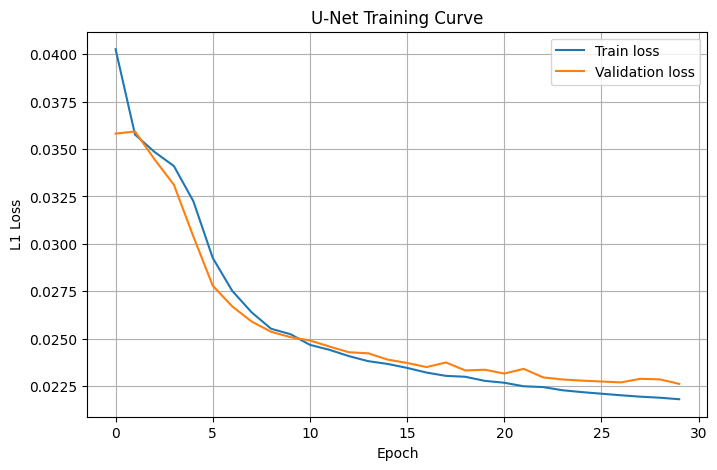

In [15]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Train loss")
plt.plot(val_losses, label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("L1 Loss")
plt.title("U-Net Training Curve")
plt.legend()
plt.grid(True)

plt.show()

In [16]:
zf_psnr_values = []
zf_ssim_values = []

unet_psnr_values = []
unet_ssim_values = []

model.eval()

with torch.no_grad():
    for x, y in val_loader:
        x = x.to(device)
        y = y.to(device)

        pred = model(x).clamp(0, 1)

        for i in range(x.shape[0]):
            zf_img = x[i, 0].cpu().numpy()
            pred_img = pred[i, 0].cpu().numpy()
            target_img = y[i, 0].cpu().numpy()

            zf_psnr_values.append(
                psnr(target_img, zf_img, data_range=1.0)
            )

            zf_ssim_values.append(
                ssim(target_img, zf_img, data_range=1.0)
            )

            unet_psnr_values.append(
                psnr(target_img, pred_img, data_range=1.0)
            )

            unet_ssim_values.append(
                ssim(target_img, pred_img, data_range=1.0)
            )

print("Zero-filled PSNR:", np.mean(zf_psnr_values))
print("U-Net PSNR:", np.mean(unet_psnr_values))

print("Zero-filled SSIM:", np.mean(zf_ssim_values))
print("U-Net SSIM:", np.mean(unet_ssim_values))

Zero-filled PSNR: 24.338195345105596
U-Net PSNR: 30.26890625297576
Zero-filled SSIM: 0.596180748491862
U-Net SSIM: 0.7374246971873993


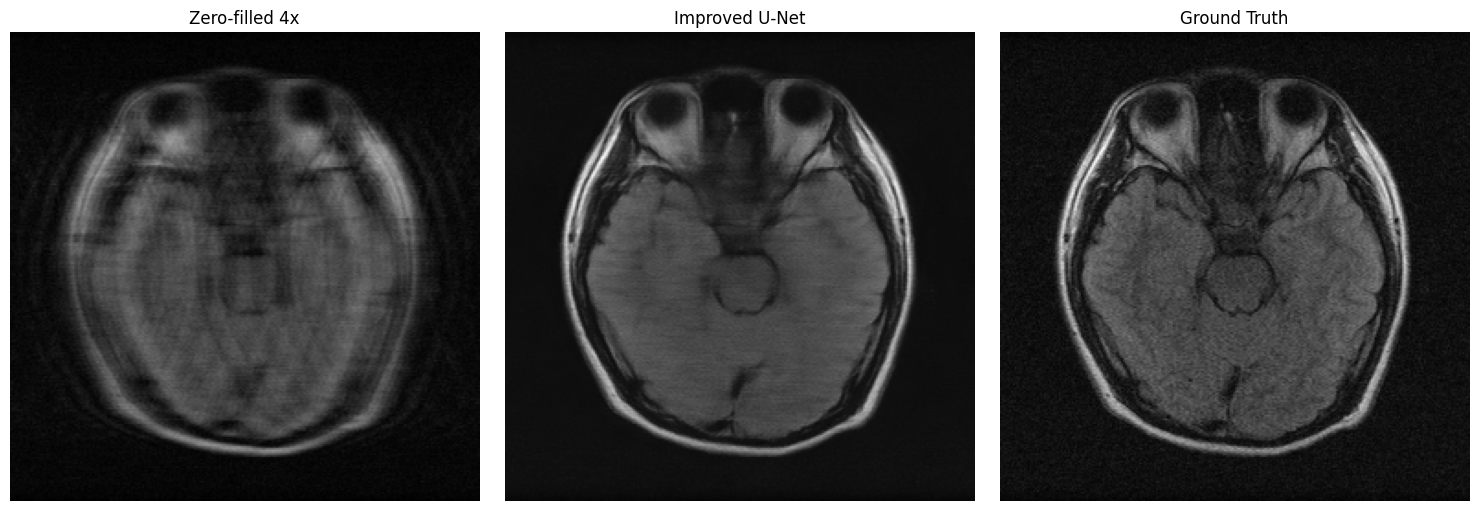

In [17]:
x, y = next(iter(val_loader))

x = x.to(device)
y = y.to(device)

with torch.no_grad():
    pred = model(x).clamp(0, 1)

idx = 0

zf_img = x[idx, 0].cpu().numpy()
pred_img = pred[idx, 0].cpu().numpy()
gt_img = y[idx, 0].cpu().numpy()

vmin = min(zf_img.min(), pred_img.min(), gt_img.min())
vmax = max(zf_img.max(), pred_img.max(), gt_img.max())

plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
plt.imshow(zf_img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Zero-filled 4x")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(pred_img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Improved U-Net")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(gt_img, cmap="gray", vmin=vmin, vmax=vmax)
plt.title("Ground Truth")
plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import os
import shutil

project_dir = "/content/drive/MyDrive/fastMRI_project"
checkpoint_dir = os.path.join(project_dir, "checkpoints")

os.makedirs(checkpoint_dir, exist_ok=True)

source_path = "best_unetbetter_4x_seed42.pth"
destination_path = os.path.join(
    checkpoint_dir,
    "best_unetbetter_4x_seed42.pth"
)

shutil.copy2(source_path, destination_path)

print("Saved permanently to:")
print(destination_path)

print("Exists:", os.path.exists(destination_path))
print("Size (MB):", round(os.path.getsize(destination_path) / 1024**2, 2))

Saved permanently to:
/content/drive/MyDrive/fastMRI_project/checkpoints/best_unetbetter_4x_seed42.pth
Exists: True
Size (MB): 22.08


In [19]:
checkpoint_path = (
    "/content/drive/MyDrive/fastMRI_project/"
    "checkpoints/best_unetbetter_4x_seed42.pth"
)

checkpoint = torch.load(checkpoint_path, map_location=device)

model = UNetBetter().to(device)
model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

print("Loaded checkpoint from epoch:", checkpoint["epoch"])

Loaded checkpoint from epoch: 30
